# Probability distributions

Checkout G.Cowan Chapter 2

## Binomial distribution

The probability to have $n$ successes in $N$ events (with probability of success $p$) is:

$$ F(n ; N, p)=\frac{N!}{n!(N-n)!} p^n(1-p)^{N-n} $$

In [2]:
import matplotlib.pyplot as plt
import numpy as np

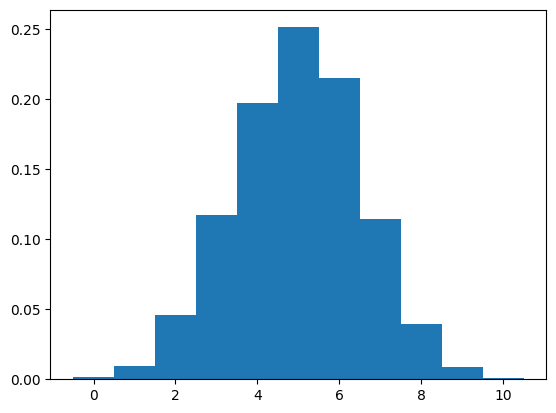

In [3]:
# generate binomial with n random trials
binomial_n, binomial_p = 10, 0.5
n_rvs = 10000
rvs = np.sum(
    np.random.uniform(size=(n_rvs, binomial_n)) > binomial_p,
    axis=1
)
plt.hist(rvs, bins=np.arange(0, binomial_n + 2) - 0.5, density=True)
plt.show()
#@title { vertical-output: true}

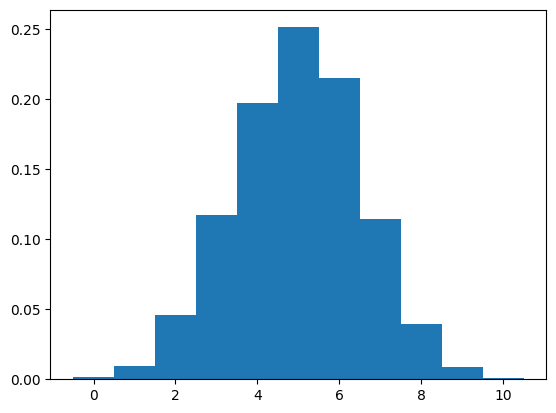

In [4]:
# example of discrete random variable
import scipy.stats as stats
mybinomial = stats.binom(n=binomial_n, p=binomial_p)
mybinomial.rvs(size=n_rvs)

plt.hist(rvs, bins=np.arange(0, binomial_n + 2) - 0.5, density=True)
plt.show()
#@title { vertical-output: true}

We can calculate the expectation value and variance of the binomial:
$$E[n] = Np$$
$$V[n] = Np(1-p)$$

In [5]:
exp_theo = binomial_n*binomial_p
var_theo = binomial_n*binomial_p*(1-binomial_p)
print(f'Expecation value: {exp_theo:.2f}')
print(f'Variance: {var_theo:.2f}')

Expecation value: 5.00
Variance: 2.50


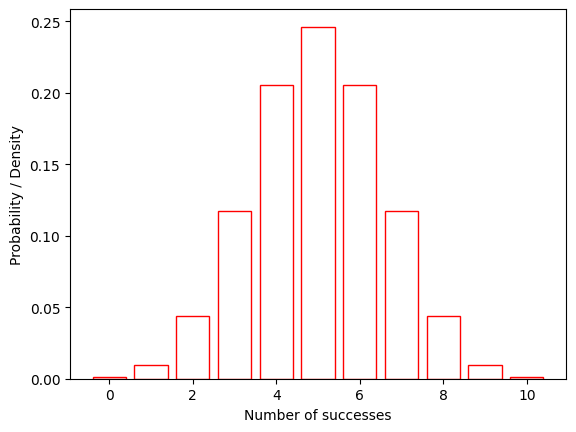

In [6]:
# Define binomial distribution parameters

binomial_n, binomial_p = 10, 0.5
mybinomial = stats.binom(n=binomial_n, p=binomial_p)

# Generate a range of values for the x-axis for the PDF
k = np.arange(0, binomial_n + 1)
# get the values of the PMF
pmf = mybinomial.pmf(k)

# plot it as a bar histogram with only the borders colored, not filled bars
plt.bar(k, pmf, color='none', edgecolor='red',  label='Binomial PMF')
plt.xlabel('Number of successes')
plt.ylabel('Probability / Density');
#@title { vertical-output: true}


We can use the binomial probability mass function to calculate numerically the expectation value and variance

$$E[n] = \sum_{i=0}^{N} F(n; N,p) \cdot n $$
$$ E[V] = E[n^2] - (E[n])^2 = \sum_{n=0}^{N} F(n;N,p)\, n^2 - (E[n])^2 $$

In [7]:
# calculate expectation value and variance
exp_value = np.sum(pmf*k)
var_value = np.sum(pmf * k**2)- exp_value**2
print(f'Expectation value: {exp_value:.2f}')
print(f'Variance: {var_value:.2f}')

Expectation value: 5.00
Variance: 2.50


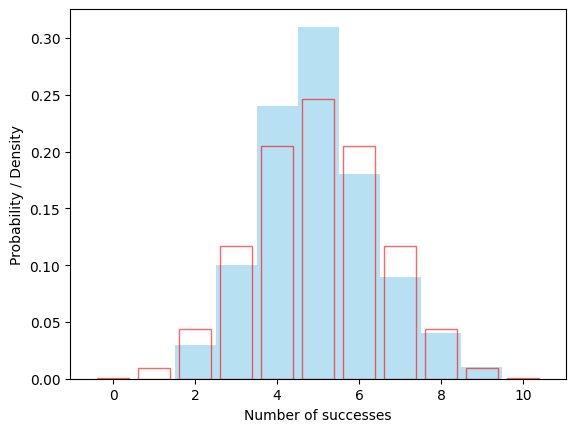

In [8]:
#@title { vertical-output: true}
# Generate random variates from the binomial distribution
rvs = mybinomial.rvs(size=100)

# Using density=True to normalize the histogram so it can be compared with the PMF
plt.hist(rvs, bins=np.arange(0, binomial_n + 2) - 0.5, density=True,
         color='skyblue', alpha=0.6, label='Histogram of 100 RVs')

# also plot the Binomial PMF from which the random variates were sampled
plt.bar(k, pmf, color='none', edgecolor='red', alpha=0.6, label='Binomial PMF');
plt.xlabel('Number of successes')
plt.ylabel('Probability / Density');

In the limit of large $N$ and small $p$ but finite expectation value of successes $Np=\nu$, the binomial becomes the **Poisson distribution**.
$$ F(n; \nu) = \frac{\nu^n}{n!}e^{-\nu} $$

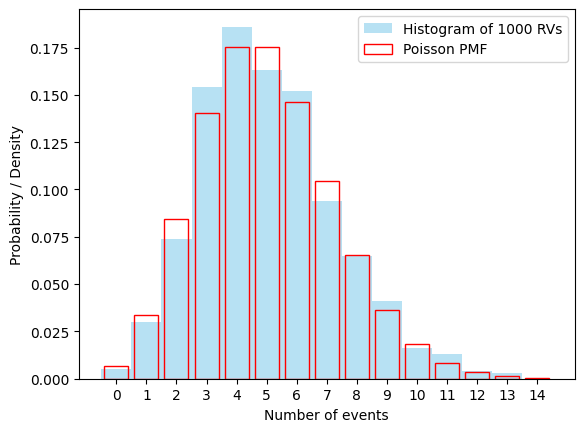

In [9]:
# Define Poisson distribution parameters
poisson_mu = 5
mypoisson = stats.poisson(mu=poisson_mu)

# Generate a range of values for the x-axis for the PMF
# A good range for Poisson is usually up to mu + 4*sqrt(mu) or a bit more
k_poisson = np.arange(0, poisson_mu + 4 * np.sqrt(poisson_mu) + 1).astype(int)

# Calculate the Probability Mass Function (PMF) for the Poisson distribution
pmf_poisson = mypoisson.pmf(k_poisson)

# Generate 1000 random variates from the Poisson distribution
rvs_poisson = mypoisson.rvs(size=1000)

# Superimpose the histogram of the random variates
# Using density=True to normalize the histogram so it can be compared with the PMF
plt.hist(rvs_poisson, bins=np.arange(0, np.max(k_poisson) + 2) - 0.5, density=True,
         alpha=0.6, color='skyblue', label='Histogram of 1000 RVs')

# Plot the PMF as bars with no fill color
plt.bar(k_poisson, pmf_poisson, color='none', edgecolor='red', label='Poisson PMF')

# Add labels and title
plt.xlabel('Number of events')
plt.ylabel('Probability / Density')
plt.xticks(np.arange(0, np.max(k_poisson) + 1, max(1, int(np.max(k_poisson)/10))))
plt.legend();
#@title { vertical-output: true}

## Continuous random variables and PDFs
Consider single continuous variable $x$. The probability of observing $x$ within an infinitesimal interval $[x, x+dx]$ is given by its probability density function $f(x)$:
$$ P([x, x+dx]) = f(x) dx $$

## The normal (Gaussian) distribution

$$ {\cal N}(x; \mu, \sigma) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{(x - \mu)^2}{2\sigma^2}} $$

which has expectation $\mu$ and variance $\sigma^2$

In [10]:
# Define Gaussian distribution parameters
gaussian_mu = 0
gaussian_std = 1
mygaussian = stats.norm(loc=gaussian_mu, scale=gaussian_std)

mygaussian.rvs(size=10)

array([-3.11880614, -0.48561489, -0.24080181,  0.52577358,  1.3374161 ,
       -0.78124566,  0.04602896, -1.42904022, -0.10108536,  0.12409504])

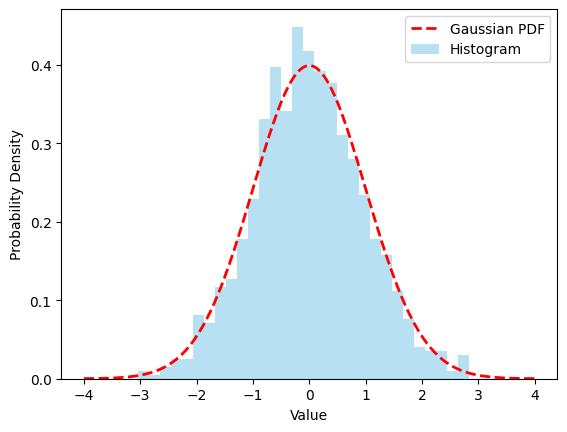

In [11]:
# Generate a range of values for the x-axis for the PDF
x_gaussian = np.linspace(gaussian_mu - 4*gaussian_std, gaussian_mu + 4*gaussian_std, 500)
# Calculate the Probability Density Function (PDF) for the Gaussian distribution
pdf_gaussian = mygaussian.pdf(x_gaussian)

# Generate 1000 random variates from the Gaussian distribution
rvs_gaussian = mygaussian.rvs(size=1000)

# Plot the PDF as a line
plt.plot(x_gaussian, pdf_gaussian, color='red', linestyle='--',
         linewidth=2, label='Gaussian PDF')

# Superimpose the histogram of the random variates
# Using density=True to normalize the histogram so it can be compared with the PDF
plt.hist(rvs_gaussian, bins=30, density=True, alpha=0.6,
         color='skyblue', label='Histogram')
plt.xlabel('Value')
plt.ylabel('Probability Density')
plt.legend();
#@title { vertical-output: true}

## Cumulative Distribution Function (CDF) and Quantile

### Cumulative Distribution Function (CDF)

For a random variable $x$, the CDF, denoted $F(x)$, gives the probability that $x$ will take a value less than or equal to $x$. It's the accumulated probability up to a certain point.

For a continuous random variable with PDF $f(x)$:
$F(x) = \int_{-\infty}^{x} f(t) \, dt$

### Quantile

The quantile is the inverse of the CDF. For a given probability $p$ (where $0 < p < 1$), the $p$-th quantile $x_p$ is the value such that the cumulative probability up to $x_p$ is $p$.

Mathematically:
$F(x_p) = p$

Common quantiles include the median (0.5-quantile) and quartiles (0.25, 0.5, 0.75-quantiles).

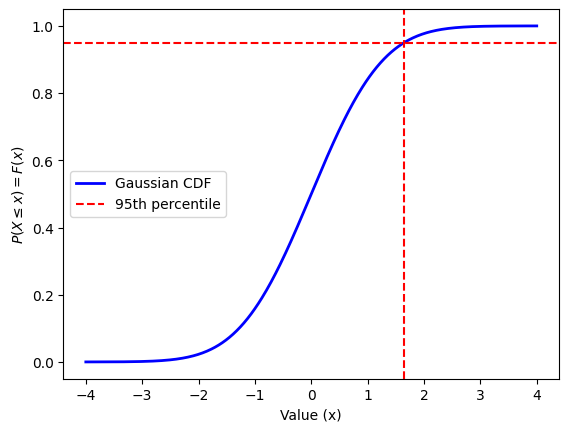

In [12]:
# Calculate the Cumulative Distribution Function (CDF)
cdf_gaussian = mygaussian.cdf(x_gaussian)

# Choose a probability to demonstrate the quantile (e.g., 95th percentile)
p_quantile = 0.95
quantile_value = mygaussian.ppf(p_quantile) # ppf is the percent point function, inverse of cdf (quantile function)

# Plot the CDF
plt.plot(x_gaussian, cdf_gaussian, color='blue', linewidth=2, label='Gaussian CDF')

# Plot lines to show the quantile
plt.axvline(x=quantile_value, color='red', linestyle='--', label=f'{p_quantile*100:.0f}th percentile')
plt.axhline(y=p_quantile, color='red', linestyle='--')

# Add labels and title
plt.xlabel('Value (x)')
plt.ylabel(r'$P(X \leq x) = F(x)$')
plt.legend();
#@title { vertical-output: true}


# The Central Limit Theorem
Given $n$ independent variables, $x_i$, distributed according to p.d.f.'s, $f_i$, having mean $\mu_i$ and variance $V_i=\sigma_i^2$, then the p.d.f. for the **sum** of the $x_i, S \equiv \sum x_i$ approaches the normal (Gaussian) p.d.f. ${\cal N}\left(S ; \sum \mu_i, \sum \sigma_i^2\right)$ as $n \rightarrow \infty$ :

$$
\lim _{n \rightarrow \infty} f(S) \rightarrow {\cal N}\left(S ; \sum_{i=1}^n \mu_i, \sum_{i=1}^n \sigma_i^2\right) \quad, \quad S=\sum_{i=1}^n x_i
$$


The CLT is the reason why the normal (Gaussian) distribution is ubiquitous and so important.

The CLT simplifies if the $f_i$ are all the same $f$ with mean $\mu$ and $V=\sigma^2$ and we divide the sum by $n$ to take the average value $\bar x = S/n$:
$$
\lim_{n\to\infty} f(\bar{x}_n)
\;\longrightarrow\;
\mathcal{N}\!\left(\bar{x}_n;\,\mu,\frac{\sigma^2}{n}\right).
$$


## Showcasing the CLT

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
n_samples = 100000  # Number of samples for each distribution
n_rvs_to_sum = [1, 2, 4, 8, 16, 100]  # Number of uniform random variables to sum

# Initiate a pdf to sample (uniform, expon, gamma, beta, chi2, lognorm)
f = stats.uniform()


# get expectation value and sqrt(variance)
f_mu, f_std = f.mean(), f.std()
print(f'mu={f_mu:.2f}, std={f_std:.2f}')

summed_distributions = []
for n_rvs in n_rvs_to_sum:
    # Generate n_rvs arrays, each with n_samples from the pdf f
    samples = f.rvs(size=(n_rvs, n_samples))

    # Average these n_rvs arrays element-wise across the first axis
    mean_rvs = np.mean(samples, axis=0)

    # Append the resulting summed distribution to the list
    summed_distributions.append(mean_rvs)

mu=0.50, std=0.29


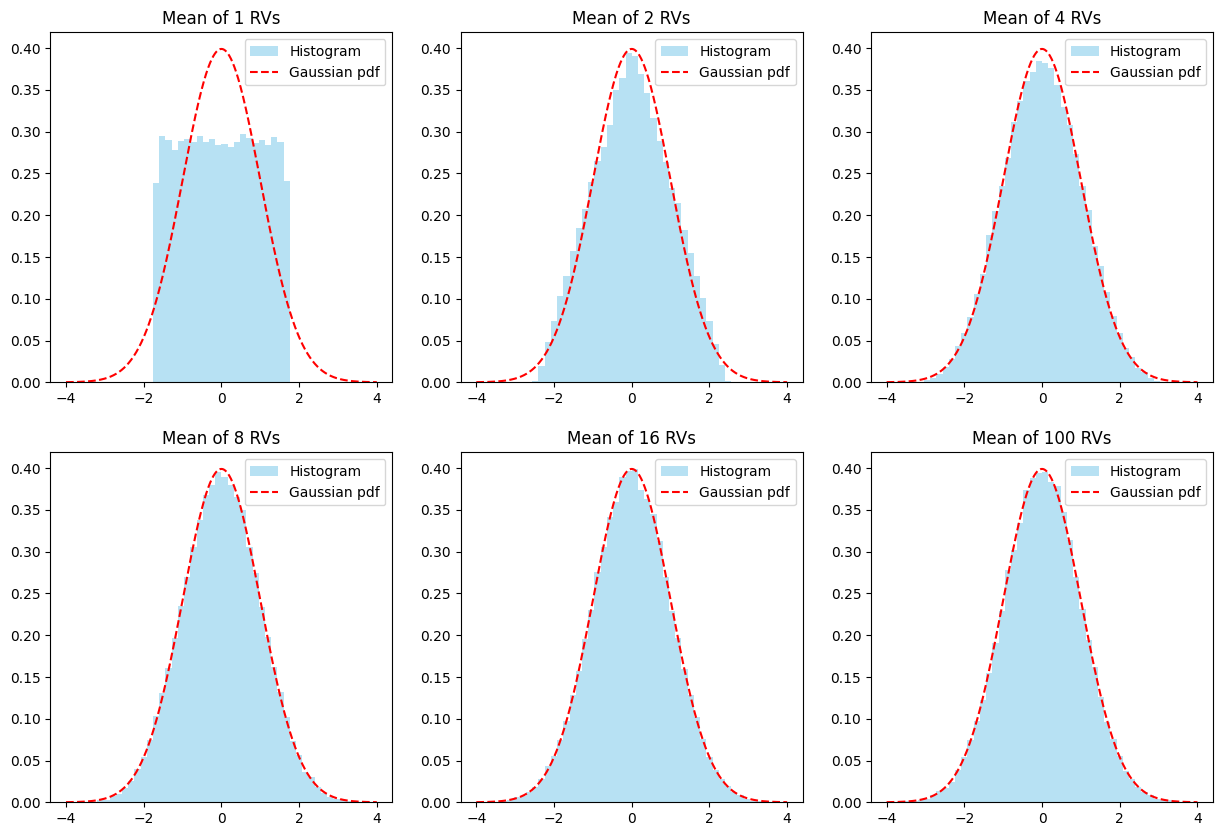

In [14]:
# Create a figure and a 2x3 grid of subplots
fig, axs = plt.subplots(2, 3, figsize=(15, 10))
axs = axs.flatten() # Flatten the 2x3 array of axes for easy iteration

# x and y to draw Gaussian PDF
gaus_x = np.linspace(-4, 4, 1000)
gaus_pdf = stats.norm.pdf(gaus_x, loc=0, scale=1)

for i, distribution in enumerate(summed_distributions):
    ax = axs[i] # Select the current subplot

    # according to CLT the distr has mu=f_mu and sigma=f_std/sqrt(N)
    distribution_scaled = (distribution - f_mu) / (f_std/np.sqrt(n_rvs_to_sum[i]))

    # Plot the histogram of the summed distribution
    ax.hist(distribution_scaled, bins=50, range=(-4,4), density=True, alpha=0.6,
            color='skyblue', label='Histogram')

    # Plot the standard Gaussian PDF curve
    ax.plot(gaus_x, gaus_pdf, 'r--', label='Gaussian pdf')

    # Set title for the subplot
    ax.set_title(f'Mean of {n_rvs_to_sum[i]} RVs')
    ax.legend()

#@title { vertical-output: true}

# Joint PDFs, Marginal and Conditional

*   The **joint PDF** $f(x, y)$ for two continuous random variables $x$ and $y$ describes the probability distribution of these variables occurring together. Its fundamental property is that the total volume under its surface must integrate to 1: $\int_{-\infty}^{\infty} \int_{-\infty}^{\infty} f(x, y) \, dx \, dy = 1$.
*   **Marginal PDFs** describe the PDF of a single random variable, where all dependence from the other variables has been integrated out:
    *   Marginal PDF of x: $f(x) = \int_{-\infty}^{\infty} f(x, y) \, dy$
    *   Marginal PDF of x: $f(y) = \int_{-\infty}^{\infty} f(x, y) \, dx$
*   **Conditional PDFs**  describe the probability distribution of one variable given a specific value of another, highlighting variable relationships. They are defined as:
    *   Conditional PDF of x given y: $f(x|y) = \frac{f(x, y)}{f(y)}$
    *   Conditional PDF of y given x: $f(y|x) = \frac{f(x, y)}{f(x)}$

* **Bayes theorem** for a conditional PDF $f(x|y)$ then reads:
$$
f(x|y)=\frac{f(y|x)\, f(x)}{f(y)}
$$
where $f(y) =\int f(y|x)\, f(x)\, dx$

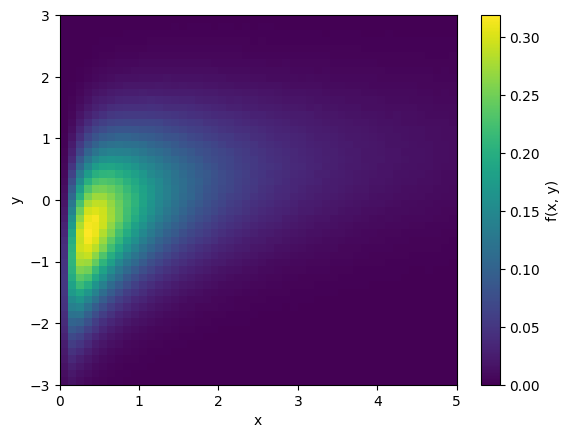

In [15]:
# generate a non-trivial 2D distribution
my_bivariate_normal = stats.multivariate_normal(
    mean=[0, 0], cov=[[1, 0.5], [0.5, 1]])
xyvals = my_bivariate_normal.rvs(size=int(1e7))
x = np.exp(xyvals[:,0])
y = xyvals[:,1]

plt.hist2d(x, y, bins=50, cmap='viridis',
           range=((0,5), (-3,3)), density=True);

plt.colorbar(label='f(x, y)')
plt.xlabel('x')
plt.ylabel('y');
#@title { vertical-output: true}

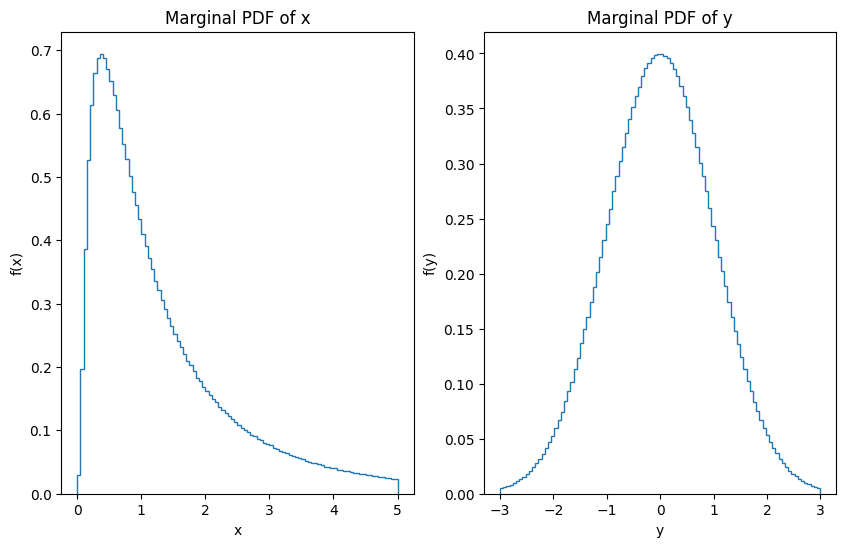

In [16]:
# Plot the marginal probability density in two panels
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.hist(x, bins=100, range=(0,5), density=True, histtype='step');
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Marginal PDF of x')

plt.subplot(1, 2, 2)
plt.hist(y, bins=100, range=(-3,3), density=True, histtype='step');
plt.xlabel('y')
plt.ylabel('f(y)')
plt.title('Marginal PDF of y');
#@title { vertical-output: true}

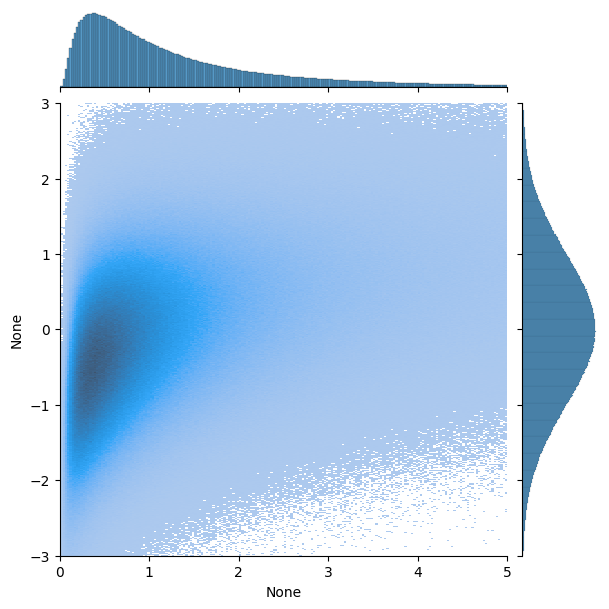

In [17]:
import seaborn as sns
sns.jointplot( x=x , y=y , kind="hist" , xlim=(0,5) , ylim=(-3,3))

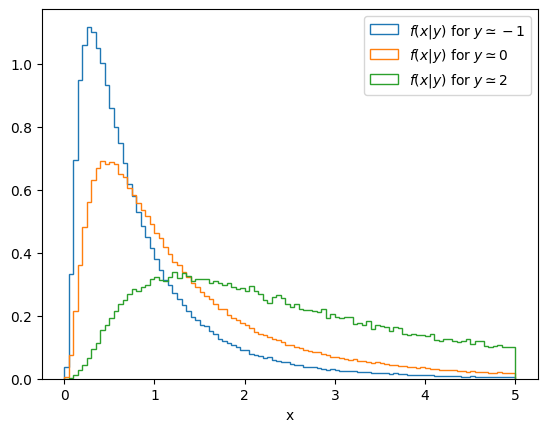

In [18]:
def plot_conditional_pdfx(yval):
  plt.hist(x[(y>yval-0.1)*(y<yval+0.1)], range=(0,5),
           bins=100, histtype='step', density=True,
           label=rf'$f(x|y)$ for $y\simeq {yval}$');

plot_conditional_pdfx(-1)
plot_conditional_pdfx(0)
plot_conditional_pdfx(2)
plt.xlabel('x')
plt.legend();
#@title { vertical-output: true}


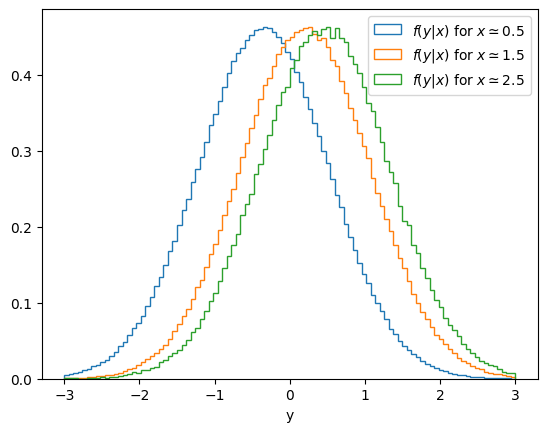

In [19]:
# now the same for f(y|x)
def plot_conditional_pdfy(xval):
  plt.hist(y[(x>xval-0.1)*(x<xval+0.1)], range=(-3,3),
           bins=100, histtype='step', density=True,
           label=rf'$f(y|x)$ for $x\simeq {xval}$');

plot_conditional_pdfy(0.5)
plot_conditional_pdfy(1.5)
plot_conditional_pdfy(2.5)
plt.xlabel('y')
plt.legend();
#@title { vertical-output: true}

## Dependence and independence
It follows from the deifnitions of marginal and conditional PDFs that:
$$ f(y) = \int f(y|x) f(x) dx $$

Now if $f(y|x)$ is independent on $x$ then:
$$ f(y) = f(y|x)\int f(x) dx = f(y|x)$$

and it follows that the joint PDF can be factorised in the marginal PDFs:
$$ f(x,y) = f(x) f(y) $$

which we take as the **definition of independent variables**.

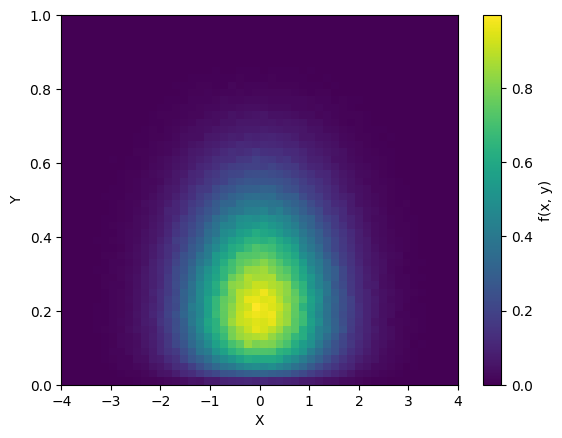

In [20]:
# example of independent random variables
x = stats.norm.rvs(loc=0, scale=1, size=int(1e6))
y = stats.beta.rvs(a=2, b=5, size=int(1e6))

plt.hist2d(x, y, bins=50, cmap='viridis',
           range=[(-4,4), (0,1)], density=True);
plt.colorbar(label='f(x, y)');
plt.ylabel('Y')
plt.xlabel('X');
#@title { vertical-output: true}


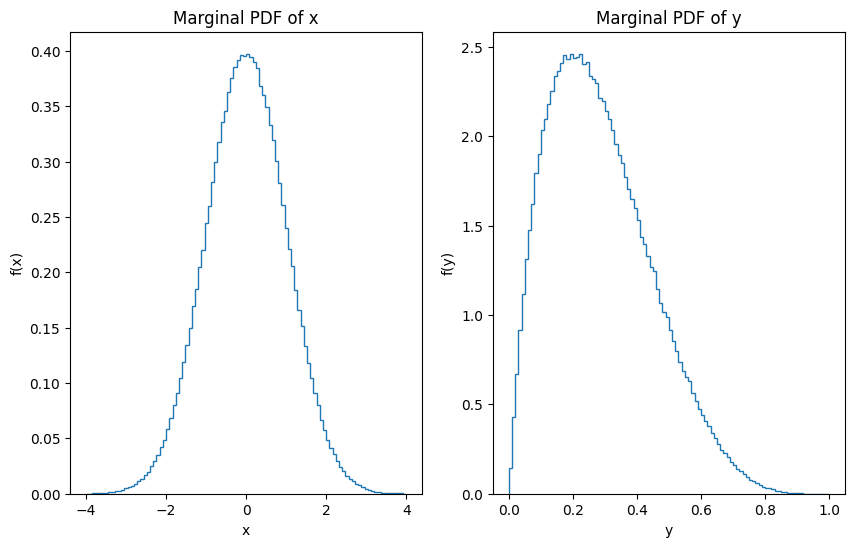

In [21]:
# Plot the marginal probability density in two panels
fig, axs = plt.subplots(1, 2, figsize=(10, 6))

plt.subplot(1, 2, 1)
plt.hist(x, bins=100, range=(-4,4), density=True, histtype='step');
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Marginal PDF of x')

plt.subplot(1, 2, 2)
plt.hist(y, bins=100, range=(0,1), density=True, histtype='step');
plt.xlabel('y')
plt.ylabel('f(y)')
plt.title('Marginal PDF of y');
#@title { vertical-output: true}

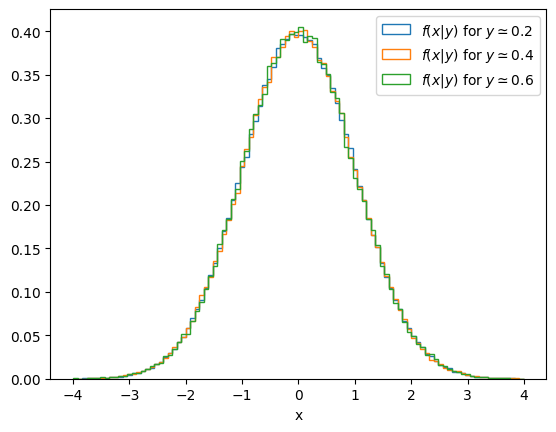

In [22]:
def plot_conditional_pdfx(yval):
  plt.hist(x[(y>yval-0.1)*(y<yval+0.1)], range=(-4,4),
           bins=100, histtype='step', density=True,
           label=rf'$f(x|y)$ for $y\simeq {yval}$');

plot_conditional_pdfx(0.2)
plot_conditional_pdfx(0.4)
plot_conditional_pdfx(0.6)
plt.xlabel('x')
plt.legend();
#@title { vertical-output: true}

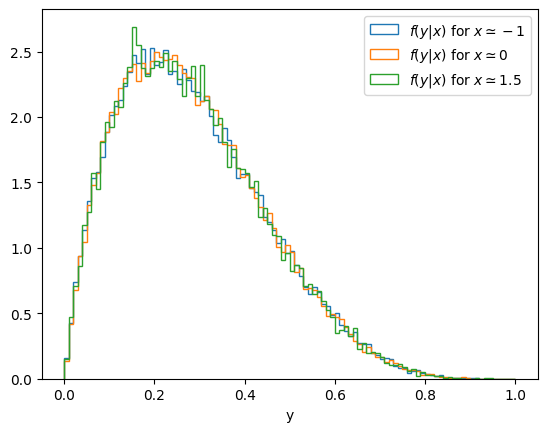

In [23]:
# now the same for f(y|x)
def plot_conditional_pdfy(xval):
  plt.hist(y[(x>xval-0.1)*(x<xval+0.1)], range=(0,1),
           bins=100, histtype='step', density=True,
           label=rf'$f(y|x)$ for $x\simeq {xval}$');

plot_conditional_pdfy(-1)
plot_conditional_pdfy(0)
plot_conditional_pdfy(1.5)
plt.xlabel('y')
plt.legend();
#@title { vertical-output: true}


# Expectation value and moments

The expectation value $E[x]$ (also called **population mean**):
$$ E[x]=\int_{-\infty}^{\infty} x f(x) d x \equiv \mu $$

The $n$th central moment of $x$ is defined as:
$$ E\left[(x-E[x])^n\right]=\int_{-\infty}^{\infty}(x-\mu)^n f(x) d x\equiv \mu_n $$
of which the second moment is called the **population variance**:
$$  E\left[(x-E[x])^2\right] = V[x] = \sigma^2 $$



## Covariance and correlation matrices

Given a two-dimensional PDF (the generalisation to more dimensions is easy), we can define the mean and variance for each variable, e.g. for $x$:
\begin{aligned}
\mu_X & =E[X]=\int_{-\infty}^{+\infty} \int_{-\infty}^{+\infty} x f(x, y) \mathrm{d} x \mathrm{~d} y \\
\sigma_X^2 & =E\left[\left(X-\mu_X\right)^2\right]
\end{aligned}

And as a measure of the dependence of $x$ on $y$ we define the **covariance** as:
$$ {\rm cov}(x,y) = E[(x-\mu_x)(y-\mu_y)] = E[xy]-\mu_x\mu_y$$

and also the dimensionless **corelation coefficient** (or correlation matrix for more than two dimensions):
$$ \rho_{xy} = \frac{{\rm cov}(x,y)}{\sigma_x\sigma_y} $$

## Warning: zero correlation $\neq$ independence
* Zero correlation if $\rho_{xy} = 0$
* Independent if $f(x,y) = f(x) f(y)$

In [24]:
# @title The dino dataset
import pandas as pd
import seaborn as sns
# Load the datasaurus dataset in a pandas dataframe
data = pd.read_csv("https://raw.githubusercontent.com/rfordatascience/tidytuesday/master/data/2020/2020-10-13/datasaurus.csv")
# Filter for the "dino" subset
dino = data.query("dataset == 'dino'")[['x','y']]

# calculate the correlation between x and y
print(dino.corr())

          x         y
x  1.000000 -0.064472
y -0.064472  1.000000


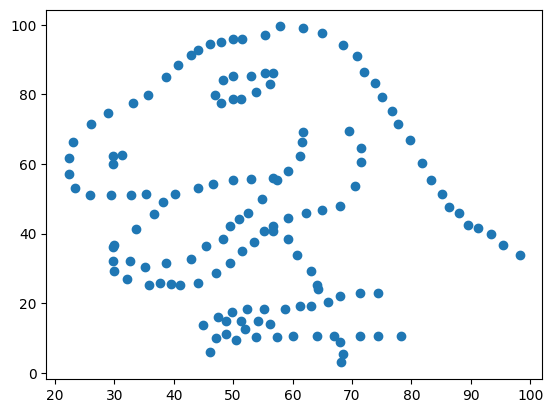

In [33]:
# create a scatter plot of the dataframe dino
plt.scatter(dino['x'], dino['y']);
#@title { vertical-output: true}

# Function of a random variable

Any function $a(x)$ of a random variable $x$ is also a random variable. What is the PDF of $a$?

If $x$ has PDF $f(x)$ and the function $a(x)$ has a unique inverse $x(a)$ then the PDF of $a$ named $g(a)$ is simply:
$$ P(x, x+dx) = P(a, a+da)$$
$$ f(x)dx = g(a) da$$
$$ g(a) = f(x(a))\left|\frac{dx}{da}\right|$$

## Example: the Lognormal PDF

If we take $a(x) = e^x$ for a random variable $x$ that follows a normal distribution ${\cal N}(x; \mu, \sigma)$, then $a$ follows a so-called log-normal distribution.

To derive the formula we need to invert $a(x)$:
$$x(a) = \ln a$$
and then calculate the PDF followed by $a$ as:
$$ g(a) = f(x(a))\left|\frac{dx}{da}\right| = {\cal N}(\ln a;\mu,\sigma) \left|\frac{d}{da}\ln a\right| = \frac{1}{a} {\cal N}(\ln a;\mu,\sigma) $$


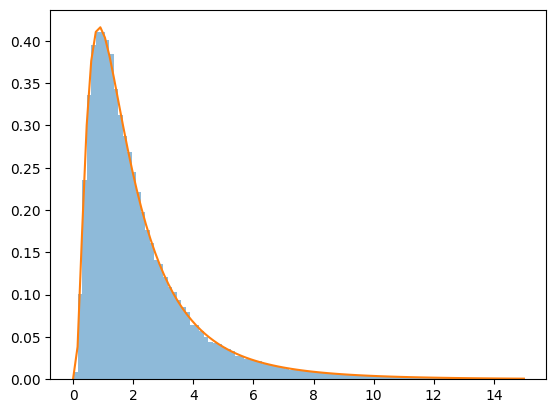

In [26]:
from scipy.stats import norm, lognorm

# Generate Gaussian samples
mu, sigma = 0.5, 0.8
x = norm.rvs(loc=mu, scale=sigma, size=100000)

# Exponentiate → lognormal samples
a = np.exp(x)

# Plot histogram
plt.hist(a, bins=100, range=(0,15), density=True, alpha=0.5)

# Theoretical lognormal PDF
a_vals = np.linspace(0, 15, 100)
pdf = lognorm.pdf(a_vals, s=sigma, scale=np.exp(mu))
plt.plot(a_vals, pdf, label="Lognormal PDF")

plt.show()
#@title { vertical-output: true}

## Why is the lognormal important?
The lognormal distribution arises whith multiplicative random processes. Imagine you have a quantity that is multiplied by a positive random factor $z_i$ (proportional change) several times:
$$ x_n = x_0 \prod_{i=1}^{n} z_i $$

Now the logarithm turns the multiplication into addition:
$$ \ln x_n = \ln x_0 + \sum_{i=1}^{n}\ln z_i $$
and if the $z_i$ are independent the CLT tells us that for large $n$:
$$ \sum_{i=1}^{n}\ln z_i \sim {\cal N}(\mu, \sigma^2)$$
meaning that $\ln x_n$ for large $n$ is approximately Gaussian and $x_n$ approximately follows a log-normal distribution.

Indeed, the lognormal distribution is very commonly found in several fields of physics, such as:
* Turbulent energy dissipation in plasma or fluid turbulence.
* Multiplicative growth of populations of nanoparticles or molecules.
* Particle physics: energy loss in radiative processes.

# Linear error propagation

Cosnider a set of random variables $\vec x = (x_1, \ldots , x_n)$ (e.g. outcome of measurements) distributed according to a joint PDF $f(\vec x)$. Now consider a function $a(\vec x)$.
Determining the PDF of $a$ is often not trivial but one can approximate its mean and variance as a function of the mean $x_i$ values $\vec \mu$ and their covariance matrix $V_{ij}$.

The derivation involves expanding $a(\vec x)$ to first order around the mean values $x_i$:
$$ a(\vec x) \simeq a(\vec \mu) + \sum_{i=1}^{n} \left[ \frac{\partial a}{\partial x_i} \right]_{\vec x = \vec \mu} (x_i - \mu_i )$$

Then it can be shown that the variance $\sigma^2_a = E[y^2] - (E[y])^2$ is iven by the **error propagation formula** :
$$ \sigma_a^2 \approx \sum_{i, j=1}^n\left[\frac{\partial a}{\partial x_i} \frac{\partial a}{\partial x_j}\right]_{\mathrm{x}=\mu} V_{i j}$$

which in the special case where the $x_i$ are uncorrelated becomes:
$$ \sigma_a^2 \approx \sum_{i=1}^n\left[\frac{\partial a}{\partial x_i} \right]^2_{\mathrm{x}=\mu} \sigma_i^2 $$

**Warning**: formula based on Taylor expansion! Approximation breaks if function $a(\vec x)$ is nonlinear over a region comparable in size to the $\sigma_i$

It turns out there is a *fantastic python package that can do linear error propagation for you*, including partial derivatives calculated analytically.

The package is called simpy `uncertainties` and can be installed via `pip`:

In [28]:
from uncertainties import ufloat, correlated_values_norm

# First define x1 and x2 variables with correlation
x1 = (2.0, 0.1) # value and std error
x2 = (3.0, 0.2) # value and std error
corr_matrix = [[1.0, 0.8],
               [0.8, 1.0]]

x1, x2 = correlated_values_norm([x1, x2], corr_matrix)

# Now we can calculate any function a(x1, x2)
a = (x1 * x2) / (x1 + x2)
# and the error is propagated using the linear approximation formula
# the partial derivatives da/dx1 and da/dx2 are calculated automatically!

print(f"x1 = {x1:.2f}, x2 = {x2:.2f}, a = {a:.2f}")

x1 = 2.00+/-0.10, x2 = 3.00+/-0.20, a = 1.20+/-0.06
